In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

# Make plots look consistent
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data = pd.read_csv(r"C:\Users\hp\Downloads\ML\iris.csv")
print(f"Dataset shape: {data.shape[0]} rows x {data.shape[1]} columns")
data.head()

Dataset shape: 150 rows x 5 columns


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
data['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [6]:
missing = data.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing values:", missing.sum())

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


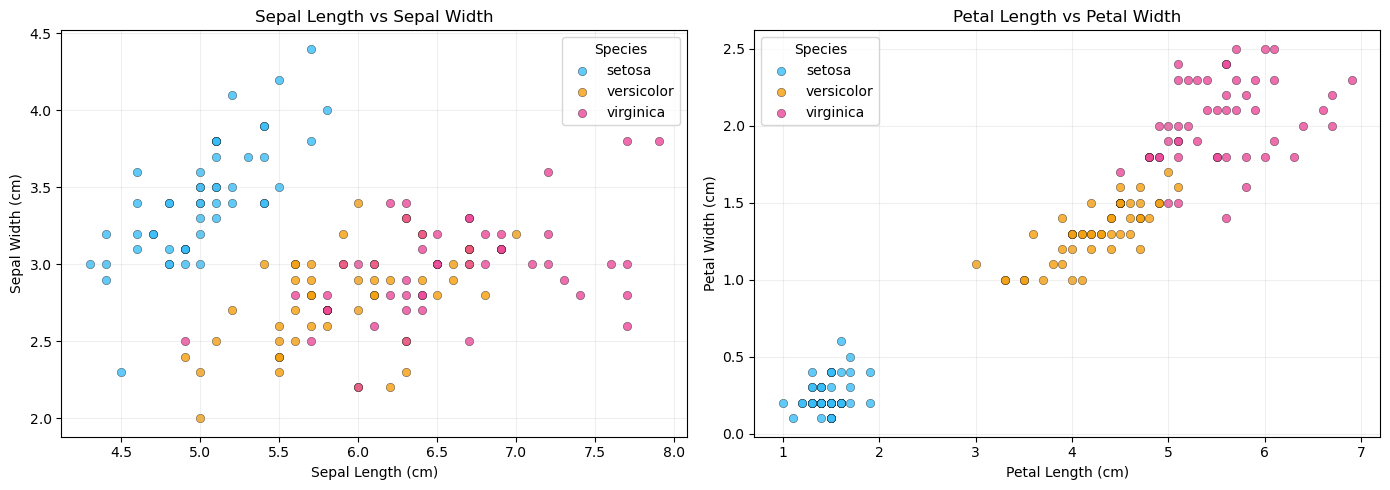

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'setosa': '#38bdf8', 'versicolor': '#f59e0b', 'virginica': '#ec4899'}

for species, grp in data.groupby('species'):
    axes[0].scatter(grp['sepal_length'], grp['sepal_width'],
                    label=species, color=colors[species], alpha=0.8, edgecolor='k', linewidth=0.3)
    axes[1].scatter(grp['petal_length'], grp['petal_width'],
                    label=species, color=colors[species], alpha=0.8, edgecolor='k', linewidth=0.3)

axes[0].set(xlabel='Sepal Length (cm)', ylabel='Sepal Width (cm)', title='Sepal Length vs Sepal Width')
axes[1].set(xlabel='Petal Length (cm)', ylabel='Petal Width (cm)', title='Petal Length vs Petal Width')
for ax in axes:
    ax.legend(title='Species'); ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()

In [8]:
X = data.drop('species', axis=1)   # features
y = data['species']                # target label

print("Features (X):", list(X.columns))
print("Target (y):  species  ->", y.unique().tolist())

Features (X): ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target (y):  species  -> ['setosa', 'versicolor', 'virginica']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")

Training set: 105 samples
Testing set:  45 samples


In [10]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
print("Decision tree trained.")
print("Tree depth:", clf.get_depth(), "| Number of leaves:", clf.get_n_leaves())

Decision tree trained.
Tree depth: 5 | Number of leaves: 8


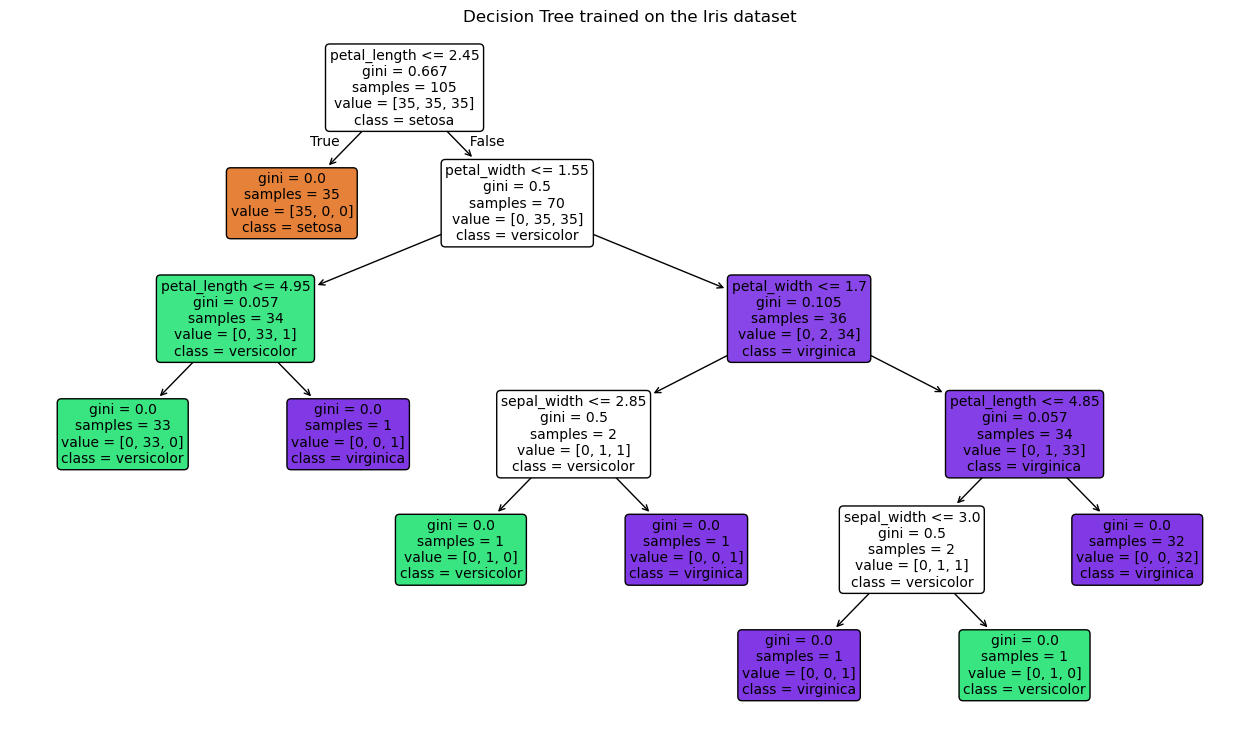

In [11]:
plt.figure(figsize=(16, 9))
plot_tree(clf,
          feature_names=X.columns,
          class_names=clf.classes_,
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree trained on the Iris dataset")
plt.show()

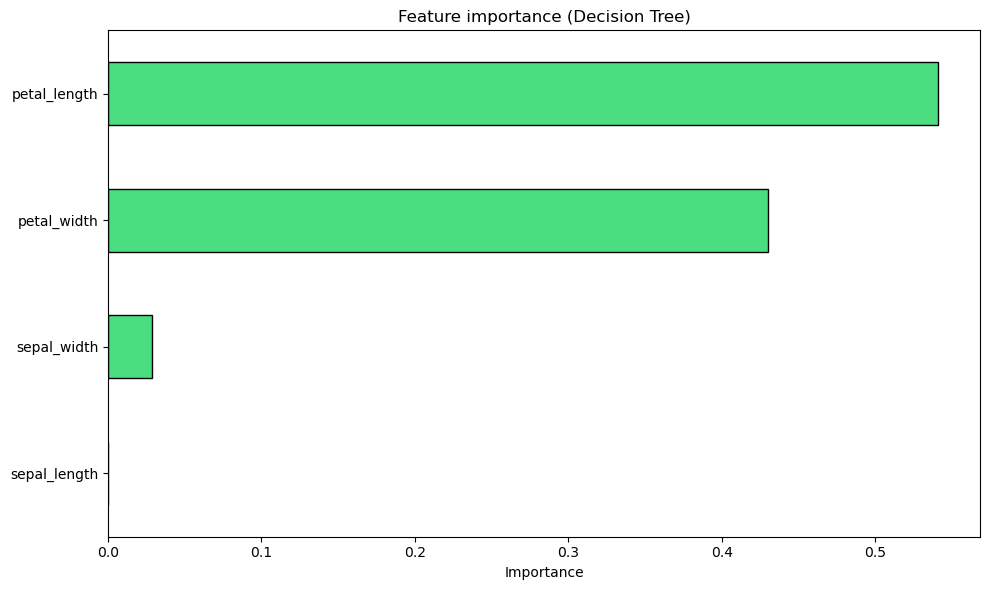

petal_length    0.541176
petal_width     0.430252
sepal_width     0.028571
sepal_length    0.000000
dtype: float64


In [12]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh', color='#4ade80', edgecolor='k')
plt.title('Feature importance (Decision Tree)')
plt.xlabel('Importance'); plt.tight_layout(); plt.show()
print(importances.sort_values(ascending=False))

In [13]:
y_pred = clf.predict(X_test)

def evaluate(name, y_true, y_hat):
    return {
        'Model': name,
        'Accuracy':  metrics.accuracy_score(y_true, y_hat),
        'Precision': metrics.precision_score(y_true, y_hat, average='weighted'),
        'Recall':    metrics.recall_score(y_true, y_hat, average='weighted'),
        'F1':        metrics.f1_score(y_true, y_hat, average='weighted'),
    }

dt_scores = evaluate('Decision Tree', y_test, y_pred)
for k, v in dt_scores.items():
    print(f"{k:10}: {v:.2f}" if isinstance(v, float) else f"{k:10}: {v}")

Model     : Decision Tree
Accuracy  : 0.93
Precision : 0.94
Recall    : 0.93
F1        : 0.93


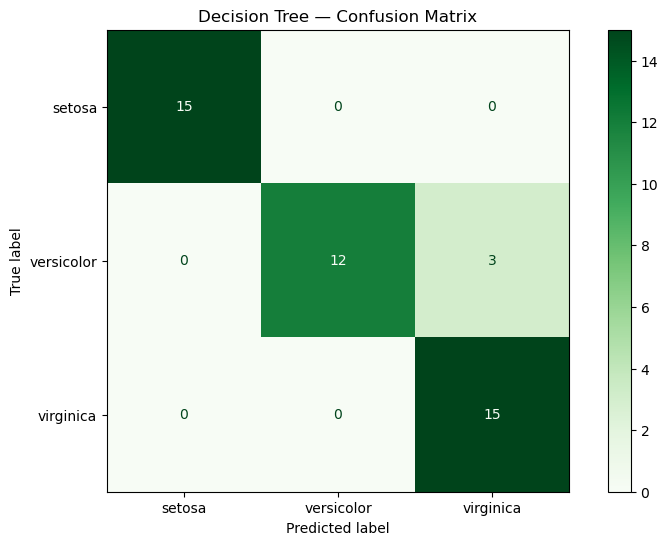

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.80      0.89        15
   virginica       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45



In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, cmap='Greens')
plt.title('Decision Tree — Confusion Matrix'); plt.show()

print(classification_report(y_test, y_pred))